# [Introduction to Data Science](http://datascience-intro.github.io/1MS041-2025/)    
## 1MS041, 2025 
&copy;2025 Raazesh Sainudiin, Benny Avelin. [Attribution 4.0 International     (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/)

# Common discrete random variables

## Bernoulli random variable

Single trial with success probability $p$.

In [1]:
from Utils import plotEMF

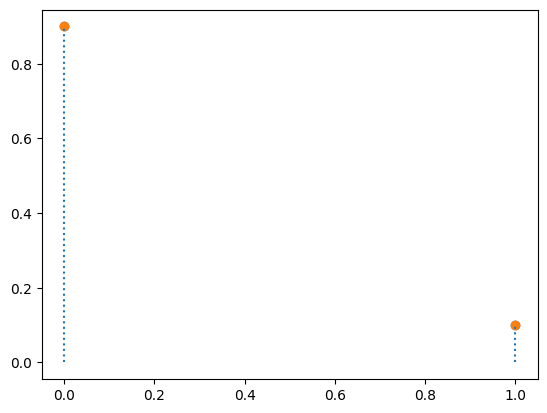

In [2]:
p = 0.1
plotEMF([(0,1-p),(1,p)])

In [3]:
import numpy as np

In [4]:
np.random.randint(0,2,size=10)

array([0, 0, 0, 1, 0, 1, 1, 1, 0, 0], dtype=int32)

In [5]:
from Utils import plotEDF,emfToEdf

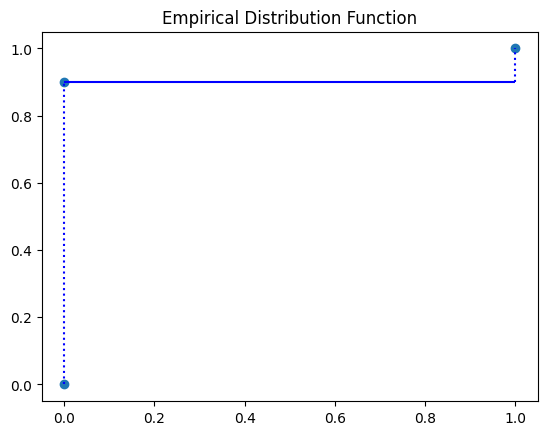

In [6]:
plotEDF(emfToEdf([(0,0),(0,1-p),(1,p)]))

In [7]:
import numpy as np

# -----------------------------
# Bernoulli Random Variable Template
# -----------------------------
# X ~ Bernoulli(p)
# p: probability of success (X=1)
# 1-p: probability of failure (X=0)

# Example: set the probability of success
p = 0.7  # change this value as required

# Number of samples to generate (if needed)
n_samples = 100  # change to required number

# ----------------------------------------
# 1. PMF (probability mass function)
# P(X = 1) = p, P(X = 0) = 1 - p
pmf_X = {0: 1 - p, 1: p}  # dictionary form

# ----------------------------------------
# 2. Generate Bernoulli samples (optional)
# Use numpy to generate n_samples of 0/1 outcomes
bernoulli_samples = np.random.binomial(1, p, size=n_samples)

# ----------------------------------------
# 3. Compute expectation and variance (optional)
# E[X] = p, Var[X] = p * (1 - p)
expected_value = p
variance = p * (1 - p)

# ----------------------------------------
# 4. Compute P(X < 1), P(X > 0) etc. (optional)
# Examples:
prob_X_less_1 = 1 - pmf_X[1]  # P(X < 1) = P(X = 0)
prob_X_greater_0 = pmf_X[1]   # P(X > 0) = P(X = 1)

# ----------------------------------------
# 5. Autograder-ready variables (example)
# Fill in the required variables for autograder submission
problem1_bernoulli_pmf = pmf_X            # dictionary {0: prob0, 1: prob1}
problem1_bernoulli_samples = bernoulli_samples  # numpy array of 0/1 samples
problem1_bernoulli_expectation = expected_value
problem1_bernoulli_variance = variance


## Binomial random variable

If we do $n$ trials with success probability $p$, then the binomial random variable is the number of successes. The PMF is
$$
    f(x) = {n \choose x} p^x (1-p)^{n-x}
$$
Can only produce numbers $0,1,\ldots,n$.

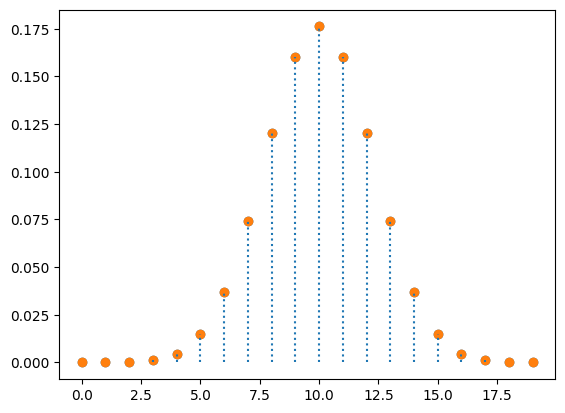

In [8]:
from scipy.special import binom as binomial
n = 20
p = 0.5
plotEMF([(i,binomial(n,i)*(p**i)*((1-p)**(n-i))) for i in range(n)])

In [9]:
np.random.binomial(20,0.5,size=10)

array([ 9,  9,  8, 13,  8, 10, 11,  9,  7,  7], dtype=int32)

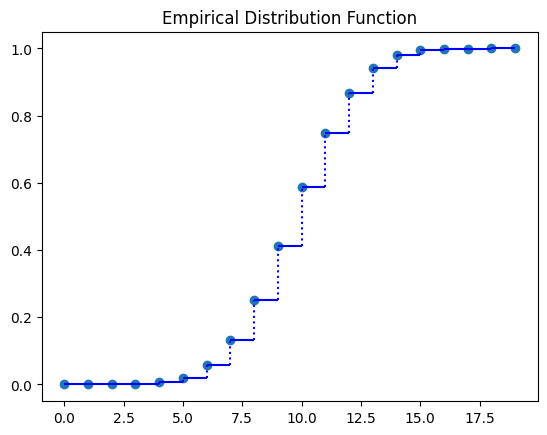

In [10]:
plotEDF(emfToEdf([(i,binomial(n,i)*(p**i)*((1-p)**(n-i))) for i in range(n)]))

In [11]:
import numpy as np
from math import comb

# -----------------------------
# Binomial Random Variable Template
# -----------------------------
# X ~ Binomial(n, p)
# n: number of trials
# p: probability of success in each trial

# Example parameters (change as needed)
n_trials = 20
p_success = 0.5

# ----------------------------------------
# 1. PMF (probability mass function)
# P(X = k) = C(n, k) * p^k * (1-p)^(n-k) for k = 0, 1, ..., n
T = np.arange(n_trials + 1)  # possible values of X: 0,1,...,n
pmf_X = np.array([comb(n_trials, k) * (p_success**k) * ((1 - p_success)**(n_trials - k)) for k in T])

# ----------------------------------------
# 2. Generate random samples from Binomial (optional)
# Use numpy to generate n_samples of X
n_samples = 100  # number of samples to generate
binomial_samples = np.random.binomial(n_trials, p_success, size=n_samples)

# ----------------------------------------
# 3. Compute expectation and variance
# E[X] = n * p, Var[X] = n * p * (1-p)
expected_value = n_trials * p_success
variance = n_trials * p_success * (1 - p_success)

# ----------------------------------------
# 4. Compute cumulative probabilities (optional)
# Example: P(X < 10), P(X > 10)
prob_X_less_10 = np.sum(pmf_X[:10])     # sum probabilities for k = 0,...,9
prob_X_greater_10 = np.sum(pmf_X[11:])  # sum probabilities for k = 11,...,n

# ----------------------------------------
# 5. Autograder-ready variables
problem1_binomial_pmf = pmf_X               # numpy array of length n+1
problem1_binomial_samples = binomial_samples # numpy array of generated samples
problem1_binomial_expectation = expected_value
problem1_binomial_variance = variance
problem1_binomial_prob_less_10 = prob_X_less_10
problem1_binomial_prob_greater_10 = prob_X_greater_10


## Poisson random variable
Pois($\lambda$) where $\lambda \in (0,\infty)$ is called the rate
$$
    f(x) = \frac{\lambda^x e^{-\lambda}}{x!}
$$

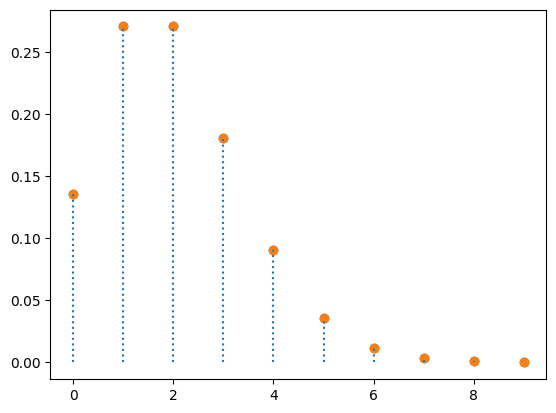

In [12]:
from scipy.special import factorial
from math import exp
l = 2
plotEMF([(i,l**i*exp(-l)/factorial(i)) for i in range(10)])

In [13]:
np.random.poisson(2,size=10)

array([3, 2, 3, 1, 2, 2, 2, 0, 4, 4], dtype=int32)

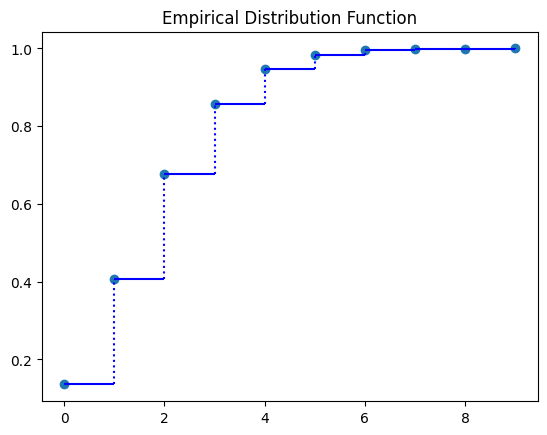

In [14]:
plotEDF(emfToEdf([(i,l**i*exp(-l)/factorial(i)) for i in range(10)]))

In [15]:
import numpy as np
from math import exp, factorial

# -----------------------------
# Poisson Random Variable Template
# -----------------------------
# X ~ Poisson(lambda)
# lambda_: expected number of events in a fixed interval

# Example parameter (change as needed)
lambda_ = 4.0

# ----------------------------------------
# 1. PMF (probability mass function)
# P(X = k) = (lambda^k * e^(-lambda)) / k! for k = 0,1,2,...
# We'll compute it up to some max value K_max for practical purposes
K_max = 15  # adjust as needed
T = np.arange(K_max + 1)  # possible values of X: 0,1,...,K_max

# Compute PMF values
pmf_X = np.array([(lambda_**k * exp(-lambda_)) / factorial(k) for k in T])

# ----------------------------------------
# 2. Generate Poisson samples (optional)
# Use numpy to generate n_samples of X
n_samples = 100  # number of samples to generate
poisson_samples = np.random.poisson(lambda_, size=n_samples)

# ----------------------------------------
# 3. Compute expectation and variance
# For Poisson: E[X] = Var[X] = lambda
expected_value = lambda_
variance = lambda_

# ----------------------------------------
# 4. Compute cumulative probabilities (optional)
# Example: P(X < 5), P(X > 7)
prob_X_less_5 = np.sum(pmf_X[:5])        # sum probabilities for k = 0,...,4
prob_X_greater_7 = np.sum(pmf_X[8:])     # sum probabilities for k = 8,...,K_max

# ----------------------------------------
# 5. Autograder-ready variables
problem1_poisson_pmf = pmf_X              # numpy array of PMF values
problem1_poisson_samples = poisson_samples # numpy array of generated samples
problem1_poisson_expectation = expected_value
problem1_poisson_variance = variance
problem1_poisson_prob_less_5 = prob_X_less_5
problem1_poisson_prob_greater_7 = prob_X_greater_7


## Empirical means

In [16]:
from random import randint

def X():
    """Produces a single random number from DeMoivre(1/3,1/3,1/3)"""
    return randint(0,2)

def empirical_mean(n=1):
    """Produces the empirical mean of n experiments of the X above"""
    Z = [X() for i in range(n)]
    return sum(Z)/n

In [17]:
# Run this to get an observation of X and rerun for another
X

<function __main__.X()>

In [18]:
# Run this to get an observation of the empirical mean of X
# when doing 10 experiments
empirical_mean(10)

1.1

In [19]:
import numpy as np

# -----------------------------
# Empirical Means Template
# -----------------------------
# Suppose we have n_samples of a random variable X
# The empirical mean is the average of these samples

# Example: generate samples from a distribution
# (here using Binomial as an example, can replace with any data)
n_samples = 100
p = 0.5
n_trials = 20

# Generate the samples
samples = np.random.binomial(n_trials, p, size=n_samples)

# ----------------------------------------
# 1. Compute the empirical mean
# The empirical mean is the sum of all samples divided by the number of samples
empirical_mean = np.mean(samples)  # equivalent to sum(samples)/n_samples

# ----------------------------------------
# 2. Compute empirical variance (optional)
# The empirical variance is the average squared deviation from the mean
empirical_variance = np.var(samples)

# ----------------------------------------
# 3. Autograder-ready variables
problem1_empirical_mean = empirical_mean
problem1_empirical_variance = empirical_variance
problem1_samples = samples  # optional: store the generated samples


# Common continuous random variables

## The uniform [0,1] random variable
In this case we have

$$
    f(x) = 
    \begin{cases}
    1 & \text{if } 0 \leq x \leq 1 \\
    0 & \text{otherwise}
    \end{cases}
$$

Also, for $x \in [0,1]$ we have

$$
    F(x) = \int_{-\infty}^x f(v) dv = \int_0^x dv = x
$$

<table style="width:95%">
  <tr>
    <th><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/96/Uniform_Distribution_PDF_SVG.svg/500px-Uniform_Distribution_PDF_SVG.svg.png" alt="500px-Uniform_Distribution_PDF_SVG.svg.png" width=250></th>
    <th><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/63/Uniform_cdf.svg/500px-Uniform_cdf.svg.png" alt="wikipedia image 500px-Uniform_cdf.svg.png" width=250></th> 
  </tr>
</table>

In [20]:
import numpy as np

In [21]:
np.array([1,2,3])

array([1, 2, 3])

In [22]:
import matplotlib.pyplot as plt

In [23]:
x = np.random.uniform(0,1,size=100)

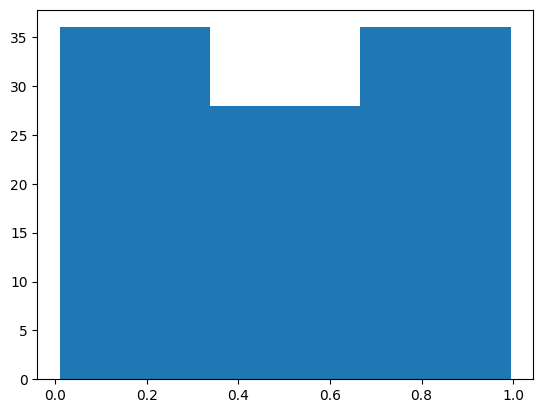

In [24]:
_=plt.hist(x,density=False,bins=3)

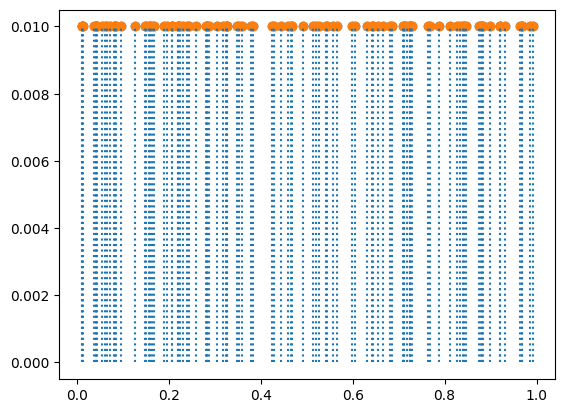

In [25]:
from Utils import makeEDF,makeEMF
plotEMF(makeEMF(np.random.uniform(size=100)))

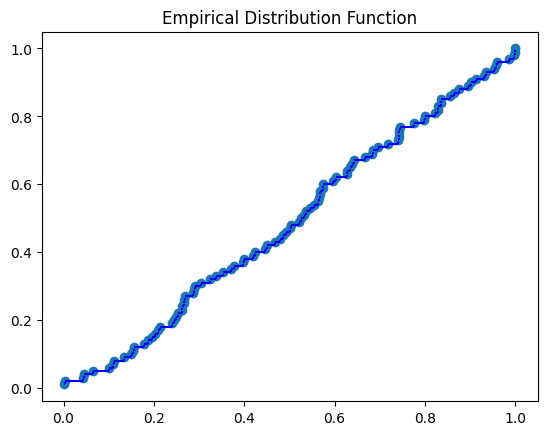

In [26]:
import numpy as np
from Utils import makeEDF,makeEMF,plotEDF
plotEDF(makeEDF(np.random.uniform(size=100)))

In [27]:
import numpy as np

# -----------------------------
# Deterministic Uniform Random Variable Template
# -----------------------------
# X ~ Uniform(a, b)
# All values in [a, b] are equally likely

# Example parameters (change as needed)
a = 0
b = 1

# ----------------------------------------
# 1. Theoretical PMF / PDF
# For a continuous uniform random variable:
# PDF: f_X(x) = 1 / (b - a) for x in [a, b], else 0
def uniform_pdf(x):
    return 1/(b - a) if a <= x <= b else 0

# Example: evaluate PDF at a few points
pdf_at_points = [uniform_pdf(x) for x in [a, (a+b)/2, b]]  # PDF at a, mid, b

# ----------------------------------------
# 2. Theoretical CDF
# CDF: F_X(x) = 0 if x < a, (x-a)/(b-a) if a<=x<=b, 1 if x>b
def uniform_cdf(x):
    if x < a:
        return 0
    elif x > b:
        return 1
    else:
        return (x - a)/(b - a)

# Example: compute CDF at a few points
cdf_at_points = [uniform_cdf(x) for x in [a, (a+b)/2, b]]

# ----------------------------------------
# 3. Expectation and Variance (theoretical)
expected_value = (a + b)/2
variance = ((b - a)**2)/12

# ----------------------------------------
# 4. Probabilities over intervals
# P(X < x0) = F_X(x0)
# P(X > x0) = 1 - F_X(x0)
x0 = 0.3
prob_X_less_x0 = uniform_cdf(x0)
prob_X_greater_x0 = 1 - uniform_cdf(x0)

# ----------------------------------------
# 5. Autograder-ready variables
problem1_uniform_pdf = pdf_at_points
problem1_uniform_cdf = cdf_at_points
problem1_uniform_expected = expected_value
problem1_uniform_variance = variance
problem1_uniform_prob_less_x0 = prob_X_less_x0
problem1_uniform_prob_greater_x0 = prob_X_greater_x0


## The Gaussian random variable (Normal)
In this case we have
$$
    f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left ( \frac{x-\mu}{\sigma}\right )}
$$
here we have two parameters, the mean $\mu$ and the standard deviation $\sigma$.

In [28]:
np.random.normal(size=10)

array([ 0.22033721,  1.63014635, -1.62807948,  0.22048217,  0.48408633,
        0.89336843,  0.86189048, -0.1207134 ,  0.32361151, -1.4170344 ])

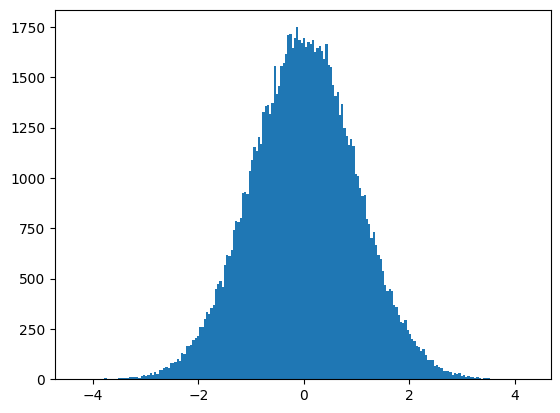

In [29]:
_=plt.hist(np.random.normal(size=100000),bins=200)

In [30]:
import numpy as np
from math import exp, sqrt, pi

# -----------------------------
# Gaussian / Normal Random Variable Template
# -----------------------------
# X ~ N(mu, sigma^2)
# mu: mean, sigma: standard deviation

# Example parameters (change as needed)
mu = 0      # mean
sigma = 1   # standard deviation

# Number of samples to generate (optional)
n_samples = 100

# ----------------------------------------
# 1. PDF of Gaussian
# f_X(x) = (1 / (sigma * sqrt(2*pi))) * exp(-(x - mu)^2 / (2*sigma^2))
def gaussian_pdf(x):
    return (1 / (sigma * sqrt(2 * pi))) * exp(-(x - mu)**2 / (2 * sigma**2))

# Evaluate PDF at some points
pdf_at_points = [gaussian_pdf(x) for x in [mu - sigma, mu, mu + sigma]]

# ----------------------------------------
# 2. CDF of Gaussian (approximation using numpy)
# P(X <= x) = integral of PDF from -infinity to x
# Use numpy's standard normal CDF
from scipy.stats import norm
def gaussian_cdf(x):
    return norm.cdf(x, loc=mu, scale=sigma)

cdf_at_points = [gaussian_cdf(x) for x in [mu - sigma, mu, mu + sigma]]

# ----------------------------------------
# 3. Generate Gaussian samples (optional)
gaussian_samples = np.random.normal(mu, sigma, size=n_samples)

# ----------------------------------------
# 4. Theoretical expectation and variance
expected_value = mu
variance = sigma**2

# ----------------------------------------
# 5. Probabilities over intervals (using CDF)
x0 = mu + sigma
x1 = mu - sigma
prob_X_less_x0 = gaussian_cdf(x0)            # P(X < x0)
prob_X_greater_x1 = 1 - gaussian_cdf(x1)    # P(X > x1)
prob_X_between = gaussian_cdf(x0) - gaussian_cdf(x1)  # P(x1 < X < x0)

# ----------------------------------------
# 6. Standardization (Z-score)
# Z = (X - mu)/sigma
z_value = (x0 - mu)/sigma
prob_Z_less_1 = norm.cdf(z_value)  # probability of Z < 1

# ----------------------------------------
# 7. Autograder-ready variables
problem1_gaussian_pdf = pdf_at_points
problem1_gaussian_cdf = cdf_at_points
problem1_gaussian_samples = gaussian_samples
problem1_gaussian_expected = expected_value
problem1_gaussian_variance = variance
problem1_gaussian_prob_less_x0 = prob_X_less_x0
problem1_gaussian_prob_greater_x1 = prob_X_greater_x1
problem1_gaussian_prob_between = prob_X_between
problem1_gaussian_z_prob = prob_Z_less_1


### PDF AND CDF 

In [31]:
import numpy as np
from math import exp, sqrt, pi
from scipy.stats import norm  # for CDF

# -----------------------------
# Gaussian / Normal PDF and CDF Fill-in Template
# -----------------------------
# X ~ N(mu, sigma^2)
mu = 0
sigma = 1

# ----------------------------------------
# 1. PDF: fill in the equation
def gaussian_pdf(x):
    # f_X(x) = ???   <--- fill in the formula here
    return (1 / (sigma * sqrt(2 * pi))) * exp(-(x - mu)**2 / (2 * sigma**2))

# ----------------------------------------
# 2. CDF: fill in using scipy or manually
def gaussian_cdf(x):
    # F_X(x) = ???   <--- fill in the formula here
    return norm.cdf(x, loc=mu, scale=sigma)

# ----------------------------------------
# 3. Evaluate PDF and CDF at example points
points = [mu - sigma, mu, mu + sigma]  # typical exam points

pdf_values = [gaussian_pdf(x) for x in points]   # PDF values
cdf_values = [gaussian_cdf(x) for x in points]   # CDF values

# ----------------------------------------
# 4. Example interval probabilities (optional)
prob_less = gaussian_cdf(mu + sigma)          # P(X < mu + sigma)
prob_greater = 1 - gaussian_cdf(mu - sigma)   # P(X > mu - sigma)
prob_between = gaussian_cdf(mu + sigma) - gaussian_cdf(mu - sigma)  # P(mu-sigma < X < mu+sigma)

# ----------------------------------------
# 5. Autograder-ready variables
problem_gaussian_pdf_points = points
problem_gaussian_pdf_values = pdf_values
problem_gaussian_cdf_points = points
problem_gaussian_cdf_values = cdf_values
problem_gaussian_prob_less = prob_less
problem_gaussian_prob_greater = prob_greater
problem_gaussian_prob_between = prob_between


# important NOTE!!!

 📚 Probability Distributions Cheat Sheet

1️⃣ Discrete Distributions

| Distribution | When to Use / Scenario | Key Parameters |
|--------------|----------------------|----------------|
| **Bernoulli** | Single trial, 2 outcomes (success/failure) | p (success probability) |
| **Binomial** | n independent Bernoulli trials, count successes | n (trials), p (success probability) |
| **Poisson** | Count rare events in fixed interval; n large, p small | λ (mean events per interval) |
| **Geometric** | Count number of trials until first success | p (success probability) |
| **Negative Binomial** | Count trials until r-th success | r (successes), p |
| **Uniform (discrete)** | Finite set of equally likely outcomes | a, b (min/max integers) |

2️⃣ Continuous Distributions

| Distribution | When to Use / Scenario | Key Parameters |
|--------------|----------------------|----------------|
| **Uniform (continuous)** | Continuous interval, all outcomes equally likely | a, b (min/max real values) |
| **Gaussian / Normal** | Continuous, natural variation, CLT applies | μ (mean), σ (std dev) |
| **Exponential** | Time until next event in Poisson process | λ (rate) |
| **Gamma** | Sum of multiple exponential events | k (shape), θ (scale) |
| **Chi-square** | Sum of squared standard normals, goodness-of-fit tests | df (degrees of freedom) |
| **Student's t** | Estimate mean with small sample, unknown variance | df (degrees of freedom) |
| **F-distribution** | Ratio of variances, ANOVA | df1, df2 (degrees of freedom) |
| **Beta** | Probability/proportion modeling (bounded 0–1) | α, β (shape parameters) |

3️⃣ Other Notes

- **Binomial-Poisson approximation**: Use Poisson if n is large, p is small. λ = n * p  
- **Empirical / Sample-based**: Use when you have raw data; compute mean, variance, probabilities from samples  

4️⃣ Quick Rules for Choosing a Distribution

1. **Counting successes/trials?**
   - 1 trial → **Bernoulli**  
   - n trials → **Binomial**  
   - Count until r-th success → **Negative Binomial**  
   - Count rare events over interval → **Poisson**  

2. **Time between events?**
   - Memoryless waiting → **Exponential**  
   - Sum of waiting times → **Gamma**  

3. **Continuous interval with equal chance?**
   - **Uniform**  

4. **Natural variation / many measurements?**
   - **Normal / Gaussian**  

5. **Data-driven / samples given?**
   - **Empirical**  

6. **Ratios / variances / small samples?**
   - t-distribution → sample mean  
   - F-distribution → ratio of variances  
   - Chi-square → sum of squared normals  

7. **Probabilities bounded between 0 and 1?**
   - **Beta**  

